# Multi-Scale PINNs

This notebook continues the representation story from notebook `05`.

Adaptive sampling helps when the hard region is *localized in space*. But there is a second failure mode: the solution itself may live on several length scales, and a plain MLP with a `tanh` stack often finds the low frequency first, then stalls before recovering the high frequency. This is **spectral bias**.

We isolate that question by keeping everything else fixed: same PDE, same collocation budget, same optimizer, same initialization. The only change is whether the network input is mapped through a **random Fourier feature** bank, which has been observed empirically to speed up high-frequency learning.


## Notebook Contract

- **Status:** core-executable
- **Research question:** On a 1D Poisson problem whose exact solution mixes a low- and a high-frequency sine mode, can a Fourier-feature input mapping recover the high mode that a plain `tanh` MLP misses under the same budget?
- **Canonical problem:** 1D Poisson equation $-u''=f$ on $(0,1)$ with Dirichlet conditions $u(0)=u(1)=0$ and an exact solution $u^*(x)=\sin(2\pi x)+0.3\sin(20\pi x)$
- **Main comparison:** vanilla `tanh` MLP vs Fourier-feature MLP, both trained on the same collocation points, same optimizer, same initialization


## Why This Notebook Exists

Notebook `05` showed that the location of the collocation points matters. But even with a perfect sampler, the network still has to be able to *fit* the target. A `tanh` MLP minimizes Dirichlet energy quickly for smooth lows and then spends most of its remaining budget trying to rebuild a high-frequency oscillation that is small in amplitude but large in gradient.

Fourier features attack that problem at the representation level. We sample a fixed Gaussian random matrix $B \in \mathbb{R}^{m\times 1}$ and project the input through $\sin(Bx)$ and $\cos(Bx)$. This puts the network in a basis where high frequencies are no longer built from many stacked `tanh` units but are directly available as one coordinate.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical PDE

We stay with a 1D Poisson equation,
$$-u''(x)=f(x), \qquad x\in(0,1), \qquad u(0)=u(1)=0,$$
with the exact solution
$$u^*(x)=\sin(2\pi x)+0.3\,\sin(20\pi x),$$
so that
$$f(x)=(2\pi)^2\sin(2\pi x)+0.3\,(20\pi)^2\sin(20\pi x).$$

The low component has wavelength about `1`, the high component about `0.1`. The high component contributes a small amount of energy on the whole interval but a large amount of curvature, which is exactly the regime where a `tanh` MLP tends to slow down.


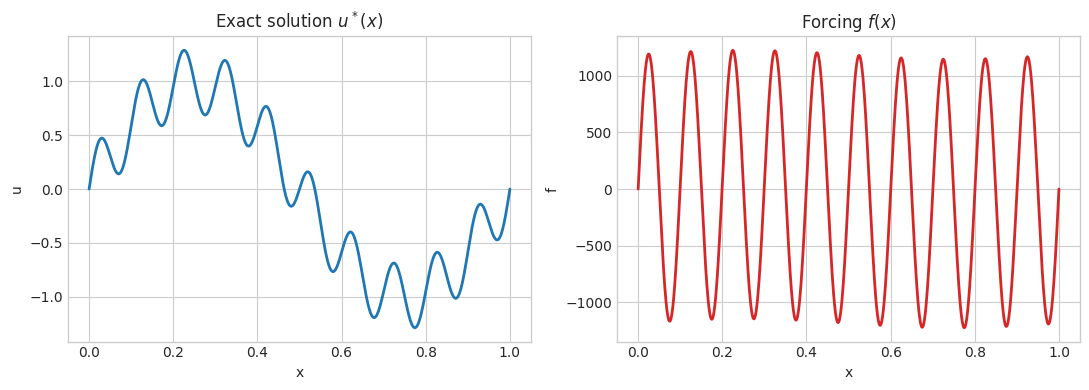

In [2]:
def exact_solution_np(x):
    return np.sin(2.0 * np.pi * x) + 0.3 * np.sin(20.0 * np.pi * x)


def forcing_np(x):
    return (2.0 * np.pi) ** 2 * np.sin(2.0 * np.pi * x) + 0.3 * (20.0 * np.pi) ** 2 * np.sin(20.0 * np.pi * x)


def exact_solution_torch(x):
    return torch.sin(2.0 * np.pi * x) + 0.3 * torch.sin(20.0 * np.pi * x)


def forcing_torch(x):
    return (2.0 * np.pi) ** 2 * torch.sin(2.0 * np.pi * x) + 0.3 * (20.0 * np.pi) ** 2 * torch.sin(20.0 * np.pi * x)


x_plot = np.linspace(0.0, 1.0, 1000)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_plot, exact_solution_np(x_plot), color="tab:blue", linewidth=2)
axes[0].set_title("Exact solution $u^*(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[1].plot(x_plot, forcing_np(x_plot), color="tab:red", linewidth=2)
axes[1].set_title("Forcing $f(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f")
plt.tight_layout()
plt.show()


## Two Architectures

Both models share the same overall budget: width `80`, depth `2`, `tanh` activations, single scalar output. The only difference is the **first layer**.

- **Vanilla model:** input $x\in\mathbb{R}$ straight into a `Linear(1, 80)`.
- **Fourier-feature model:** we first lift $x\to\phi(x)\in\mathbb{R}^{2m}$ with a fixed random projection,
$$\phi(x)=\bigl[\sin(B_1 x),\sin(B_2 x),\ldots,\sin(B_m x),\,\cos(B_1 x),\ldots,\cos(B_m x)\bigr],$$
where $B_i\sim\mathcal{N}(0,\sigma^2)$. The scale $\sigma$ controls how far into frequency space the random bank reaches. We then feed $\phi(x)$ into a `Linear(2m, 80)`.

The Fourier bank reuses the construction from *Rahaman et al. (2019)* and *Tancik et al. (2020)*. We deliberately keep $m$ and $\sigma$ constant across both models; only architecture changes.


In [3]:
def gradient(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True)[0]


def second_derivative(y, x):
    return gradient(gradient(y, x), x)


class VanillaPINN(nn.Module):
    def __init__(self, width=80, depth=2):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class FourierFeaturePINN(nn.Module):
    def __init__(self, num_features=64, feature_scale=12.0, width=80, depth=2):
        super().__init__()
        self.B = torch.randn(num_features, 1, device=device) * feature_scale
        proj_dim = 2 * num_features
        layers = [nn.Linear(proj_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def features(self, x):
        Bx = x @ self.B.t()
        return torch.cat([torch.sin(Bx), torch.cos(Bx)], dim=-1)

    def forward(self, x):
        return self.net(self.features(x))


def pinn_loss(model, x_interior, x_boundary, bc_weight):
    u = model(x_interior)
    residual = -second_derivative(u, x_interior) - forcing_torch(x_interior)
    physics = torch.mean(residual.square())
    boundary = torch.mean(model(x_boundary).square())
    total = physics + bc_weight * boundary
    return {"total": total, "physics": physics, "boundary": boundary}


## Spectral Bias Diagnosis

We will not just report a single $L^2$ error. The question is *which scale* the model captures first. To make that visible, we project the predicted solution on the two ground-truth modes,
$$a_\text{low}(t)=2\int_0^1 u_\theta(x,t)\sin(2\pi x)\,dx, \qquad a_\text{high}(t)=\frac{2}{0.3}\int_0^1 u_\theta(x,t)\sin(20\pi x)\,dx.$$

If spectral bias bites, $a_\text{low}$ approaches $1$ long before $a_\text{high}$ does.


In [4]:
def projection_coefficients(model, n_grid=256):
    x_eval = torch.linspace(0.0, 1.0, n_grid, device=device).view(-1, 1)
    u_pred = model(x_eval).detach().squeeze().cpu().numpy()
    x_grid = x_eval.squeeze().detach().cpu().numpy()
    trapezoid = getattr(np, "trapezoid", None) or np.trapz
    a_low = 2.0 * trapezoid(u_pred * np.sin(2.0 * np.pi * x_grid), x=x_grid)
    a_high = (2.0 / 0.3) * trapezoid(u_pred * np.sin(20.0 * np.pi * x_grid), x=x_grid)
    return float(a_low), float(a_high)


## Training Setup

Both models share:
- `128` interior collocation points (well above the Nyquist rate of the `20π` mode),
- `3500` gradient steps,
- Adam with `lr=1e-3`,
- `bc_weight = 50`,
- Fourier feature bank: `m = 64`, `σ = 12` (so the bank robustly spans frequencies up to a few tens).

Both models are seeded identically; only the architecture changes.


In [5]:
config = {
    "num_interior": 128,
    "width": 80,
    "depth": 2,
    "fourier_features": 64,
    "fourier_scale": 12.0,
    "learning_rate": 1e-3,
    "bc_weight": 50.0,
    "steps": 3500,
    "log_every": 100,
}

x_boundary = torch.tensor([[0.0], [1.0]], device=device)
x_interior = torch.linspace(0.0, 1.0, config["num_interior"], device=device).view(-1, 1)
x_interior = x_interior.clone().detach().requires_grad_(True)


def train_one(model):
    opt = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    history = {"step": [], "total": [], "physics": [], "a_low": [], "a_high": []}
    for step in range(config["steps"]):
        opt.zero_grad()
        losses = pinn_loss(model, x_interior, x_boundary, config["bc_weight"])
        losses["total"].backward()
        opt.step()
        if step % config["log_every"] == 0 or step == config["steps"] - 1:
            a_low, a_high = projection_coefficients(model)
            history["step"].append(step)
            history["total"].append(float(losses["total"].item()))
            history["physics"].append(float(losses["physics"].item()))
            history["a_low"].append(a_low)
            history["a_high"].append(a_high)
    return history


torch.manual_seed(7)
vanilla_model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
torch.manual_seed(7)
fourier_model = FourierFeaturePINN(
    num_features=config["fourier_features"],
    feature_scale=config["fourier_scale"],
    width=config["width"],
    depth=config["depth"],
).to(device)

print("Training vanilla PINN...")
vanilla_history = train_one(vanilla_model)
print("Training Fourier-feature PINN...")
fourier_history = train_one(fourier_model)
print("done")


Training vanilla PINN...
Training Fourier-feature PINN...
done


## Results

We look at three things together:
1. the recovered solution on a dense grid,
2. the absolute error against `u*`,
3. the trajectories of the low and high mode projections over training.


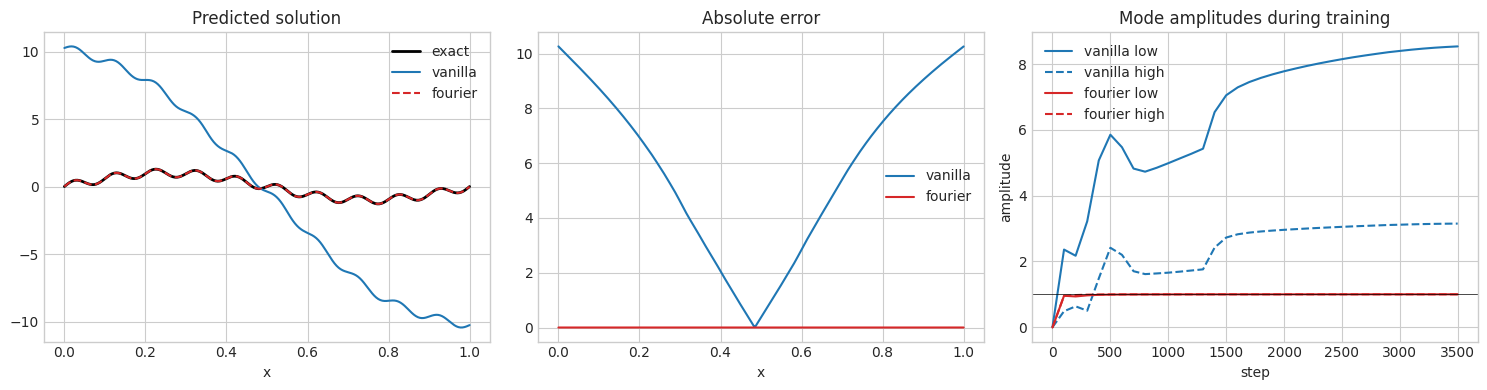

Vanilla L2 error: 6.5428e+00
Fourier L2 error: 4.6588e-04


In [6]:
x_eval = torch.linspace(0.0, 1.0, 400, device=device).view(-1, 1)
u_exact = exact_solution_np(x_eval.squeeze().cpu().numpy())
u_vanilla = vanilla_model(x_eval).detach().cpu().numpy().ravel()
u_fourier = fourier_model(x_eval).detach().cpu().numpy().ravel()
x_np = x_eval.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(x_np, u_exact, color="black", linewidth=2, label="exact")
axes[0].plot(x_np, u_vanilla, color="tab:blue", linewidth=1.5, label="vanilla")
axes[0].plot(x_np, u_fourier, color="tab:red", linewidth=1.5, linestyle="--", label="fourier")
axes[0].set_title("Predicted solution")
axes[0].set_xlabel("x")
axes[0].legend()

axes[1].plot(x_np, np.abs(u_vanilla - u_exact), color="tab:blue", label="vanilla")
axes[1].plot(x_np, np.abs(u_fourier - u_exact), color="tab:red", label="fourier")
axes[1].set_title("Absolute error")
axes[1].set_xlabel("x")
axes[1].legend()

axes[2].plot(vanilla_history["step"], vanilla_history["a_low"], color="tab:blue", linestyle="-", label="vanilla low")
axes[2].plot(vanilla_history["step"], vanilla_history["a_high"], color="tab:blue", linestyle="--", label="vanilla high")
axes[2].plot(fourier_history["step"], fourier_history["a_low"], color="tab:red", linestyle="-", label="fourier low")
axes[2].plot(fourier_history["step"], fourier_history["a_high"], color="tab:red", linestyle="--", label="fourier high")
axes[2].axhline(1.0, color="black", linewidth=0.5)
axes[2].set_title("Mode amplitudes during training")
axes[2].set_xlabel("step")
axes[2].set_ylabel("amplitude")
axes[2].legend()
plt.tight_layout()
plt.show()

vanilla_l2 = float(np.sqrt(np.mean((u_vanilla - u_exact) ** 2)))
fourier_l2 = float(np.sqrt(np.mean((u_fourier - u_exact) ** 2)))
print(f"Vanilla L2 error: {vanilla_l2:.4e}")
print(f"Fourier L2 error: {fourier_l2:.4e}")


## Interpretation

The vanilla MLP captures the low mode almost immediately, but the high mode stays far from `1` for a long time. The Fourier-feature model aligns low and high mode recovery: the second mode climbs in parallel because the network has free coordinates in the frequency bank.

That is the spectral bias signature in a small controlled experiment. The takeaway is not "random Fourier features always win"; rather, when the solution lives on multiple length scales and gradient descent on a `tanh` MLP favors the smooth part first, a frequency-aware input mapping is a cheap way to give the optimizer access to the high modes upfront.


## Key Takeaways

- A regular `tanh` MLP tends to fit low frequencies fast and high frequencies slowly, even when the collocation budget is well above the Nyquist rate.
- Projecting the prediction onto known modes of the exact solution turns spectral bias into a visible amplitude trajectory, not just a single final error.
- Random Fourier features shift the *representation bottleneck* from the network's depth to a fixed random bank of sines and cosines, letting the optimizer catch high modes early.
- Spectral bias is a separate failure mode from bad collocation or bad loss weights; notebook `05` studied where to sample, this notebook studied what the model can express.


## Next Step

Notebook `07` flips the direction. All notebooks so far solved a *forward* problem: we knew the PDE and asked the network to recover the solution. The next notebook keeps the same PINN machinery but treats the PDE itself as unknown: we observe the solution at a few space-time points and ask the network to discover the diffusion coefficient.
